In [1]:
# flows/function1_flow.py

import sys, os
try:
    # Works when running as a normal Python script
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    # Fallback for Jupyter/IPython where __file__ is not defined
    project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from data.BaseDataHandler import BaseDataHandler
from optimisation.BayesOptUtils import BayesOptUtils
from plotting.PlotUtils import PlotUtils
from Function1DataHandler import Function1DataHandler  # same folder
from models.SurrogateNN import SurrogateTrainer
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (14, 9)
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['font.size'] = 12

import numpy as np
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 0)                  # Use unlimited width (auto-detect terminal size)
pd.set_option('display.expand_frame_repr', False)  # Prevent wrapping to multiple lines


    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
14    0.469395    1.050091     -6.688485e-142  week-5
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
13    0.436769    0.825163      -1.519972e-55  week-4
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file


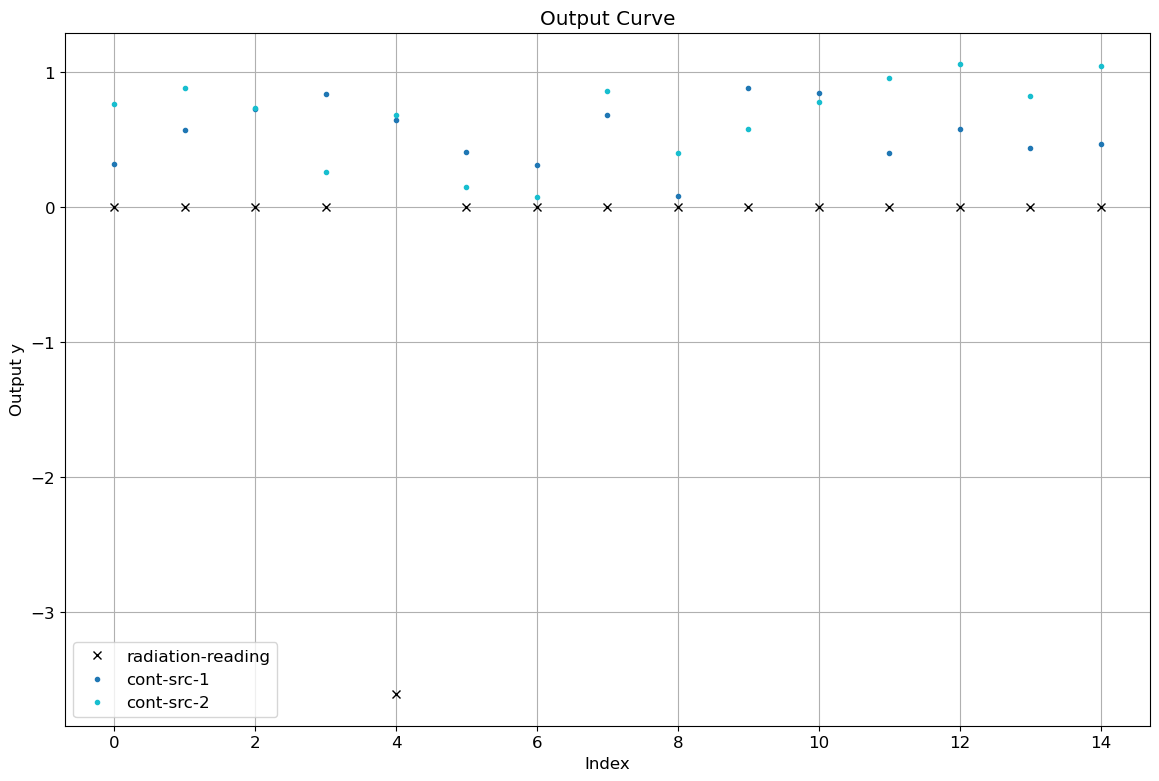

In [2]:
# --- Data ---
dh = Function1DataHandler()
dh.add_weekly_updates()
df_sorted = dh.build_dataframe()
print(df_sorted)
plotter = PlotUtils()
plotter.plot_output_points(
    df_sorted,
    scale_factor=1.0,
    yield_scale_factor=1000.0,
    source_marker='week-x',          # highlight all rows with source == 'week-x'
    source_color='red',
    source_marker_style='x'
)
X, y = dh.inputs, dh.outputs

# --- Utilities ---
utils = BayesOptUtils()
trainer = SurrogateTrainer(input_dim=X.shape[1], lr=1e-3, epochs=500)


Epoch 1/500, Train Loss: 1.247756, Val Loss: 0.080170
Epoch 50/500, Train Loss: 0.778509, Val Loss: 0.089798
Early stopping at epoch 84, best val_loss=0.041499
PRINTING HISTORY: {'train_losses': [1.2477563619613647, 1.230399250984192, 1.2150264978408813, 1.2013143301010132, 1.18941068649292, 1.1785351037979126, 1.1684046983718872, 1.1591020822525024, 1.1505928039550781, 1.1424306631088257, 1.1344306468963623, 1.1267555952072144, 1.1192296743392944, 1.112535834312439, 1.1055824756622314, 1.0983468294143677, 1.0914146900177002, 1.084246277809143, 1.0770728588104248, 1.0696653127670288, 1.0621713399887085, 1.0543330907821655, 1.046395182609558, 1.0381842851638794, 1.0297552347183228, 1.0215156078338623, 1.013037919998169, 1.004233479499817, 0.9951214790344238, 0.9857621192932129, 0.9770781397819519, 0.9683094024658203, 0.9589822292327881, 0.949544370174408, 0.9401342868804932, 0.9304202198982239, 0.9202561378479004, 0.9101158976554871, 0.8997554779052734, 0.889215886592865, 0.878474652767

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


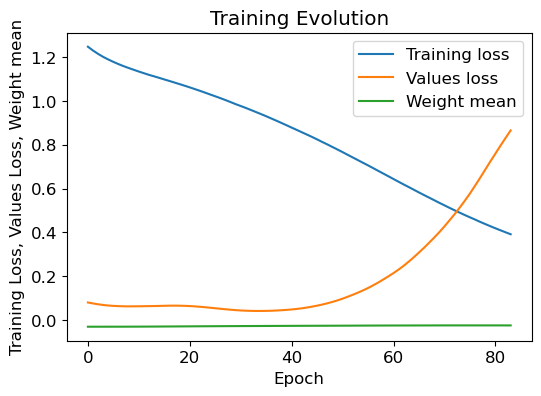

Using 2 dimensions.
Points before downsampling: 10000
Points after downsampling: 10000
Final grid shape: (10000, 2)
Filtered 216 candidates near decision boundary (|margin| < 0.2)
Excluded 9784 candidates from consideration
Final grid shape: (216, 2)
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.4579111, 1.0641719]), 'score': 0.9181864410239687, 'dim': 2, 'predicted_y': 0.3025717}
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.40733622, 1.02838786]), 'score': 0.1801916685936117, 'dim': 2, 'predicted_y': 0.30712917}
{'method': 'PI', 'xi': 0.3, 'kappa': None, 'x': array([0.3365314, 0.8733237]), 'score': 0.0008670834678969737, 'dim': 2, 'predicted_y': 0.22412561}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.40733622, 1.02838786]), 'score': 0.0438232057806522, 'dim': 2, 'predicted_y': 0.30712917}
{'method': 'EI', 'xi': 0.1, 'kappa': None, 'x': array([0.40733622, 1.02838786]), 'score': 0.006427548170552272, 'dim': 2, '

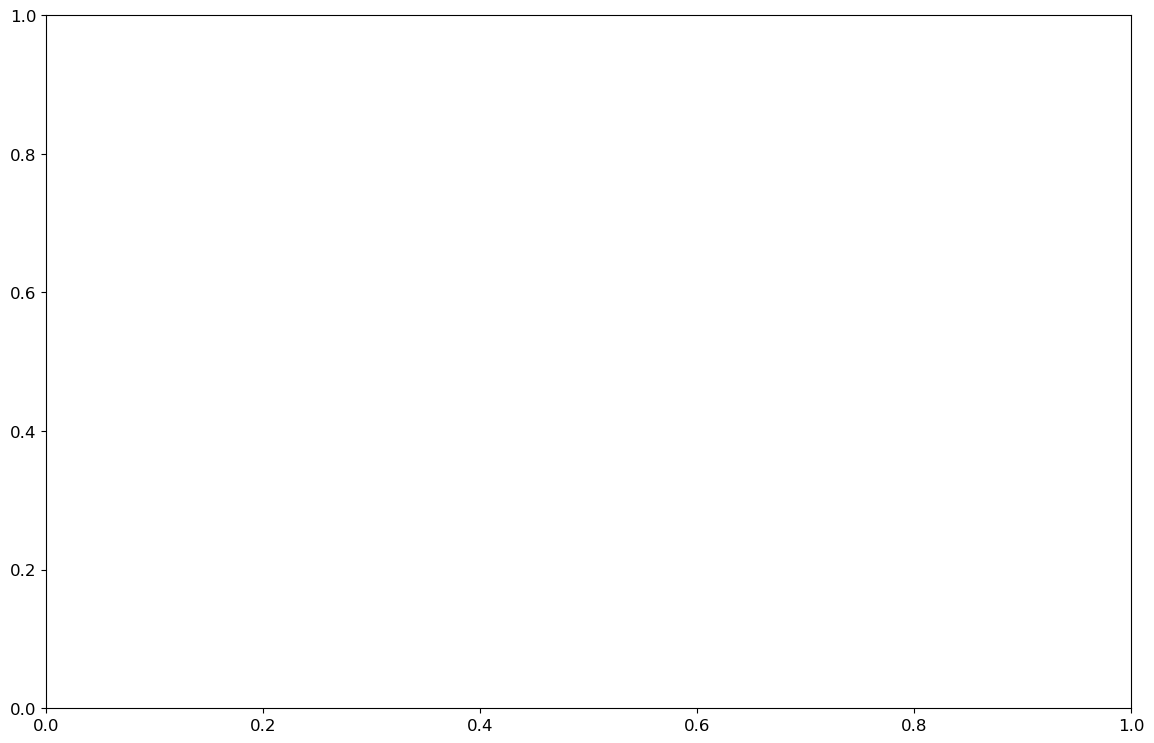

In [3]:

# --- Hyperparameters supplied here ---
xi_values = [0.01, 0.1, 0.3]
kappa_values = [1.0, 2.0, 3.0]
grid_sizes = [100]
methods = ['PI', 'EI', 'UCB']
apply_scaling = True
filter_mode = 'gp'

# --- Run flow ---
results = utils.run_flow(
    trainer, X, y,
    xi_values=xi_values,
    kappa_values=kappa_values,
    grid_sizes=grid_sizes,
    methods=methods,
    apply_scaling=apply_scaling,
    filter_mode=filter_mode
)



=== Results for grid_size=100 ===


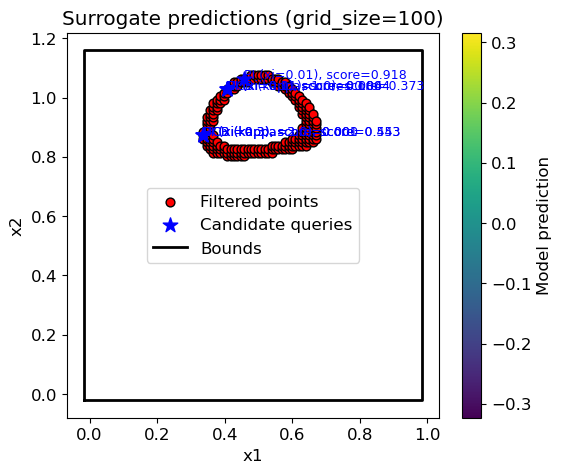

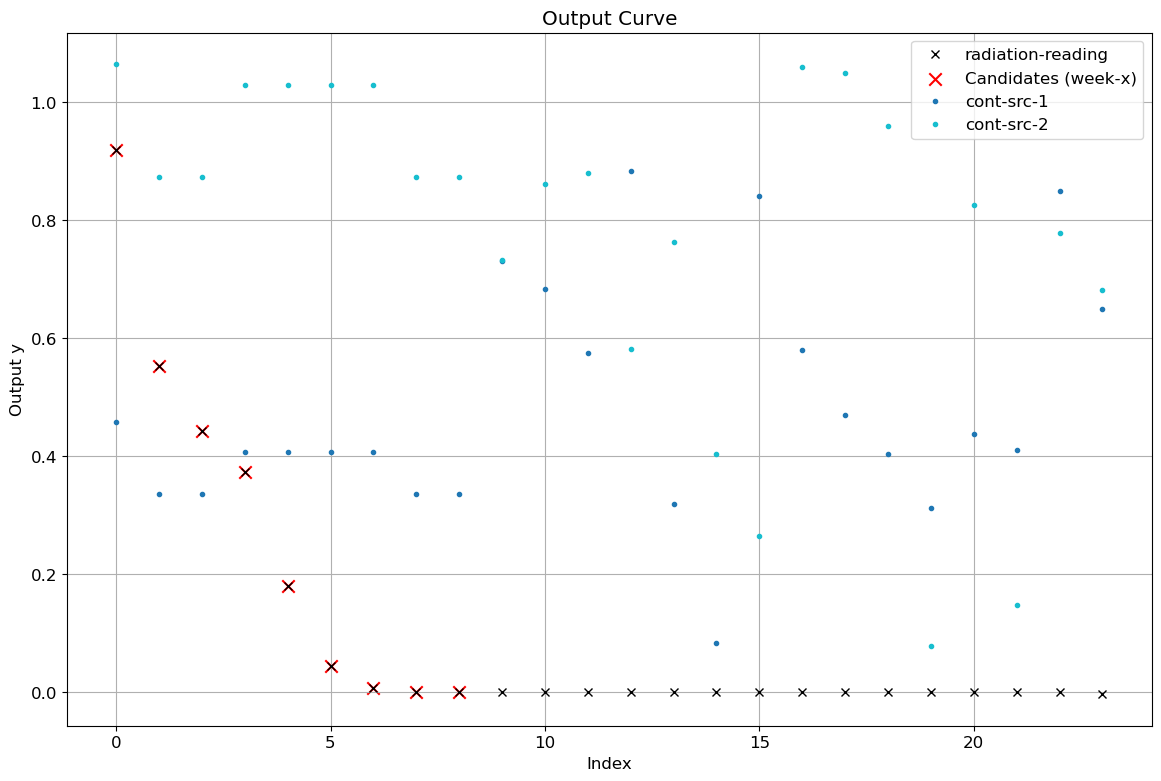

    cont-src-1  cont-src-2  radiation-reading  source  radiation-reading-scaled
0     0.457911    1.064172       9.181864e-01  week-x              1.000000e+01
1     0.336531    0.873324       5.527635e-01  week-x              6.020167e+00
2     0.336531    0.873324       4.432176e-01  week-x              4.827098e+00
3     0.407336    1.028388       3.728735e-01  week-x              4.060978e+00
4     0.407336    1.028388       1.801917e-01  week-x              1.962474e+00
5     0.407336    1.028388       4.382321e-02  week-x              4.772800e-01
6     0.407336    1.028388       6.427548e-03  week-x              7.000265e-02
7     0.336531    0.873324       8.670835e-04  week-x              9.443436e-03
8     0.336531    0.873324       2.602879e-05  week-x              2.834804e-04
9     0.731024    0.733000       7.710875e-16    file              8.397941e-15
10    0.683418    0.861057       2.535001e-40    file              2.760878e-39
11    0.574329    0.879898       1.03307

In [4]:
# --- Loop over results and plot ---
for grid_size, (X_grid_filtered, mean, bounds, best, query_results, acq_maps) in results.items():
    print(f"\n=== Results for grid_size={grid_size} ===")

    # Extract candidates and labels
    candidates, labels = plotter.extract_candidates_and_labels(query_results, include_score=True)

    # Surrogate predictions plot
    plotter.plot_surrogate_generic(
        X_grid_filtered, mean,
        X_filtered=X_grid_filtered,
        bounds=bounds,
        candidates=candidates,
        candidate_labels=labels,
        title=f"Surrogate predictions (grid_size={grid_size})"
    )
    # get candidate arrays (K,d) and predicted y (K,)
    cand_array, y_pred_array = dh.extract_candidate_arrays(query_results)

    # create a copy with candidates appended (no change to dh or df_global)
    df_copy, new_indices = dh.append_candidates_to_df_copy(
        candidates=cand_array,
        predicted_y=y_pred_array,
        source_label="week-x",    # or f"grid-{grid_size}"
        feature_cols=None,        # or explicit list if you want
        yield_col=None,           # or explicit yield column name
        source_col="source"
    )
    df_copy_sorted = df_copy.sort_values(by=df_copy.columns[-2], ascending=False, na_position='last').reset_index(drop=True)
    # plot the copy and highlight appended rows by source or indices
    plotter.plot_output_points(
        df_copy_sorted,
        scale_factor=1.0,
        yield_scale_factor=1.0,
        source_marker="week-x",   # highlights by source label
        source_color="red",
        source_marker_style="x"
    )
    
    col = df_copy_sorted.columns[-2]
    max_val = df_copy_sorted[col].max(skipna=True)
    df_copy_sorted[f"{col}-scaled"] = (df_copy_sorted[col].astype(float) * (10.0 / max_val)) if (pd.notna(max_val) and max_val != 0) else np.nan    

    print(df_copy_sorted)
    # Print best candidate info
    print("Best candidate:", best)
